# EXPERIMENT 1 REAL


## 1. Imports and configuration

In [12]:
import numpy as np, pandas as pd, re
import xml.etree.ElementTree as ET
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
from scipy.stats import wilcoxon

# ---- data locations ----
MASTER_CSV = Path("master_experiments.csv")
WORLDS_DIR = Path("generated_worlds_single_sensor")

# ---- fixed DBSCAN (same for baseline and kernel) ----
FIXED_EPS, MIN_PTS = 0.12, 3

# ---- kernel parameters ----
ALPHA_MIN, ALPHA_MAX = 0.30, 0.70
TAU      = 1.5      # m
S_OBJ_M  = 0.40     # m  (representative object width; justified in the text)

# ---- ground-truth tolerance ----
SURFACE_MARGIN_M = 0.12

# ---- distance bins (m) for reporting ----
DIST_BINS   = [0, 3, 6, np.inf]
DIST_LABELS = ["near (<3 m)", "mid (3-6 m)", "far (>6 m)"]

## 2. The clean kernel (single source of truth)

In [13]:
from ds_dbscan.kernel import schedule_alpha, transition_range, warp_polar

def sigmoid(z): return 1.0 / (1.0 + np.exp(-z))

def r0_from_device(s_obj_m, dtheta_deg, min_pts=MIN_PTS):
    """Transition range: comes only from the sensor step and object size."""
    return transition_range(s_obj_m, min_pts, np.deg2rad(dtheta_deg))

def alpha_schedule(r_bar_m, r0_m):
    return schedule_alpha(r_bar_m, r0_m, ALPHA_MIN, ALPHA_MAX, TAU)

def points_euclidean(df):
    r  = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    return np.column_stack([r*np.cos(th), r*np.sin(th)])

def points_kernel(df, s_obj_m):
    r  = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    r_bar = np.median(r)
    r0    = r0_from_device(s_obj_m, float(df["resolution"].iloc[0]))
    alpha = alpha_schedule(r_bar, r0)
    return warp_polar(r, th, alpha), alpha

def run_dbscan(pts):
    return DBSCAN(eps=FIXED_EPS, min_samples=MIN_PTS).fit_predict(pts)

def n_clusters(lab):  return len(set(lab)) - (1 if -1 in lab else 0)
def noise_pct(lab):   return 100.0 * np.sum(lab == -1) / len(lab)

## 3. World parsing + ground truth


In [14]:
def parse_world(path):
    txt  = re.sub(r'\sxmlns="[^"]+"', '', path.read_text())
    root = ET.fromstring(txt)
    sensor, structures = {"x":0.0,"y":0.0,"yaw":0.0}, []
    for model in root.iter("model"):
        name = model.get("name","")
        pose = model.findtext("pose","0 0 0 0 0 0").split()
        x, y, yaw = float(pose[0]), float(pose[1]), float(pose[5])
        if "lidar" in name.lower() or "sensor" in name.lower():
            sensor = {"x":x,"y":y,"yaw":yaw}; continue
        box = model.find(".//box/size")
        cyl = model.find(".//cylinder/radius")
        is_obs = name.lower().startswith("obstacle")
        if box is not None:
            sx, sy, _ = (float(v) for v in box.text.split())
            structures.append((name,"rect",x,y,sx,sy,yaw,is_obs))
        elif cyl is not None:
            structures.append((name,"circ",x,y,float(cyl.text),0.0,yaw,is_obs))
    return {"sensor":sensor, "structures":structures}

def _in_rect(px,py,cx,cy,sx,sy,yaw,m):
    dx,dy = px-cx, py-cy
    c,s = np.cos(-yaw), np.sin(-yaw)
    lx, ly = dx*c - dy*s, dx*s + dy*c
    return (np.abs(lx) <= sx/2+m) & (np.abs(ly) <= sy/2+m)

def _in_circ(px,py,cx,cy,r,m):
    return (px-cx)**2 + (py-cy)**2 <= (r+m)**2

def ground_truth_labels(df, world, margin=SURFACE_MARGIN_M):
    s  = world["sensor"]
    r  = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values) + s["yaw"]
    px, py = s["x"] + r*np.cos(th), s["y"] + r*np.sin(th)
    labels = np.full(len(df), -1, dtype=int)
    is_obs = np.zeros(len(df), dtype=bool)
    free   = np.ones(len(df), dtype=bool)
    for i,(nm,kind,cx,cy,a,b,yaw,obs) in enumerate(world["structures"]):
        inside = _in_rect(px,py,cx,cy,a,b,yaw,margin) if kind=="rect" else _in_circ(px,py,cx,cy,a,margin)
        hit = inside & free
        labels[hit] = i; is_obs[hit] = obs; free[hit] = False
    return labels, is_obs

## 4. Load data

In [15]:
worlds = {p.name: parse_world(p) for p in WORLDS_DIR.glob("*.world")}
print(f"Loaded {len(worlds)} worlds")

master_df = pd.read_csv(MASTER_CSV)
master_df = master_df[np.isfinite(master_df["distance_mm"]) &
                      np.isfinite(master_df["angle_deg"])].copy()
print(f"{len(master_df):,} points across {master_df['environment_id'].nunique()} environments")

Loaded 100 worlds
24,232 points across 100 environments


## 5. Main evaluation loop (baseline vs kernel)

In [16]:
rows = []
for env in master_df["environment_id"].unique():
    df = master_df[master_df["environment_id"] == env]
    if len(df) < MIN_PTS: continue
    wname = df["world_file"].iloc[0]
    if wname not in worlds: continue
    world = worlds[wname]

    dtheta = float(df["resolution"].iloc[0])
    r_bar  = df["distance_mm"].median() / 1000.0
    y_true, is_obs = ground_truth_labels(df, world)
    true_obs = sum(1 for st in world["structures"] if st[7])   # number of obstacle structures

    lab_b = run_dbscan(points_euclidean(df))
    pts_k, alpha = points_kernel(df, S_OBJ_M)
    lab_k = run_dbscan(pts_k)

    # full-scene ARI
    ari_b_full = adjusted_rand_score(y_true, lab_b)
    ari_k_full = adjusted_rand_score(y_true, lab_k)
    # obstacle-only ARI
    if is_obs.sum() >= 2:
        ari_b_obs = adjusted_rand_score(y_true[is_obs], lab_b[is_obs])
        ari_k_obs = adjusted_rand_score(y_true[is_obs], lab_k[is_obs])
    else:
        ari_b_obs = ari_k_obs = np.nan
    # obstacle cluster-count error
    cc_b = n_clusters(lab_b[is_obs]) if is_obs.sum() else 0
    cc_k = n_clusters(lab_k[is_obs]) if is_obs.sum() else 0

    rows.append(dict(env=env, resolution=dtheta, distance=r_bar, alpha=alpha,
        true_obstacles=true_obs,
        ari_b_obs=ari_b_obs, ari_k_obs=ari_k_obs,
        ari_b_full=ari_b_full, ari_k_full=ari_k_full,
        noise_b=noise_pct(lab_b), noise_k=noise_pct(lab_k),
        cc_err_b=abs(cc_b-true_obs), cc_err_k=abs(cc_k-true_obs)))

res = pd.DataFrame(rows)
res["dist_bin"] = pd.cut(res["distance"], bins=DIST_BINS, labels=DIST_LABELS)
print(f"Processed {len(res)} environments")
res.head()

Processed 100 environments


,env,resolution,distance,alpha,true_obstacles,ari_b_obs,ari_k_obs,ari_b_full,ari_k_full,noise_b,noise_k,cc_err_b,cc_err_k,dist_bin
0,env_000_res2.0deg_180samp_o12_r9.0x4.5,2.0,3.703440,0.507748,12,0.331514,1.000000,0.099936,0.574695,66.666667,7.222222,9,3,mid (3-6 m)
1,env_001_res2.0deg_180samp_o15_r8.2x6.4,2.0,2.045715,0.606171,15,0.137243,0.485714,0.402574,0.355162,42.222222,30.000000,14,13,near (<3 m)
2,env_002_res1.5deg_240samp_o14_r6.6x8.9,1.5,3.921565,0.574352,14,0.388492,0.957628,0.301564,0.567382,45.000000,6.666667,10,5,mid (3-6 m)
3,env_003_res1.5deg_240samp_o8_r9.7x6.8,1.5,7.606470,0.363068,8,0.460805,0.968254,0.070175,0.462391,73.750000,1.250000,6,2,far (>6 m)
4,env_004_res4.0deg_90samp_o6_r6.4x5.4,4.0,1.438440,0.531172,6,0.000000,0.283286,0.276347,0.627952,53.333333,35.555556,6,5,near (<3 m)


## 6. Headline numbers

In [17]:
def wins(a, b): return int((a > b).sum())   # how often kernel beats baseline
print("HEADLINE (all scans)")
print(f"  Obstacle ARI : {res['ari_b_obs'].mean():.3f} -> {res['ari_k_obs'].mean():.3f}"
      f"  | kernel wins {wins(res['ari_k_obs'],res['ari_b_obs'])}/{res['ari_k_obs'].notna().sum()}")
print(f"  Full ARI     : {res['ari_b_full'].mean():.3f} -> {res['ari_k_full'].mean():.3f}")
print(f"  Noise %%      : {res['noise_b'].mean():.1f} -> {res['noise_k'].mean():.1f}")
print(f"  ClusterErr   : {res['cc_err_b'].mean():.2f} -> {res['cc_err_k'].mean():.2f}")

HEADLINE (all scans)
  Obstacle ARI : 0.395 -> 0.768  | kernel wins 88/100
  Full ARI     : 0.278 -> 0.568
  Noise %%      : 56.0 -> 21.7
  ClusterErr   : 7.34 -> 5.47


## 7. Grouped by DISTANCE bin and by RESOLUTION

In [18]:
def summary(group_col):
    g = res.groupby(group_col, observed=True)
    out = pd.DataFrame({
        "n":           g.size(),
        "ARIobs base": g["ari_b_obs"].mean(),
        "ARIobs kern": g["ari_k_obs"].mean(),
        "Noise base":  g["noise_b"].mean(),
        "Noise kern":  g["noise_k"].mean(),
        "CCerr base":  g["cc_err_b"].mean(),
        "CCerr kern":  g["cc_err_k"].mean(),
    })
    return out.round(3)

print("=== by DISTANCE bin ==="); print(summary("dist_bin")); print()
print("=== by RESOLUTION ===");   print(summary("resolution"))

=== by DISTANCE bin ===
              n  ARIobs base  ARIobs kern  Noise base  Noise kern  CCerr base  \
dist_bin                                                                        
near (<3 m)  41        0.439        0.708      43.732      23.170       8.171   
mid (3-6 m)  46        0.395        0.815      60.198      18.282       7.152   
far (>6 m)   13        0.253        0.792      79.487      29.092       5.385   

             CCerr kern  
dist_bin                 
near (<3 m)       7.049  
mid (3-6 m)       4.783  
far (>6 m)        2.923  

=== by RESOLUTION ===
             n  ARIobs base  ARIobs kern  Noise base  Noise kern  CCerr base  \
resolution                                                                     
0.5         15        0.930        0.945       7.991       0.231       3.800   
1.5         23        0.532        0.882      48.228       7.010       6.130   
2.0         21        0.294        0.828      59.048      13.069       7.762   
3.0         15   

## 8. Paired significance tests (Wilcoxon)

In [19]:
def wtest(a, b, name):
    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m], b[m]
    try: _, p = wilcoxon(a, b)
    except Exception: p = np.nan
    print(f"  {name:14s}: mean {a.mean():.3f} vs {b.mean():.3f}  p={p:.2e}  n={len(a)}")

print("Kernel vs baseline (paired, all scans):")
wtest(res['ari_k_obs'].values,  res['ari_b_obs'].values,  "Obstacle ARI")
wtest(res['ari_k_full'].values, res['ari_b_full'].values, "Full ARI")
wtest(res['noise_b'].values,    res['noise_k'].values,    "Noise %")   # baseline higher = better for kernel
wtest(res['cc_err_b'].values,   res['cc_err_k'].values,   "ClusterErr")

Kernel vs baseline (paired, all scans):
  Obstacle ARI  : mean 0.768 vs 0.395  p=3.32e-16  n=100
  Full ARI      : mean 0.568 vs 0.278  p=4.98e-17  n=100
  Noise %       : mean 55.954 vs 21.692  p=5.69e-18  n=100
  ClusterErr    : mean 7.340 vs 5.470  p=2.34e-13  n=100


## 9. Sensitivity to `s_obj`
Re-run the kernel for a few object widths. Ground truth does not depend on `s_obj`, so
only the kernel labels change. A stable result across a sensible range is the strongest
answer to *"why 0.40 and not 0.25?"*.

In [20]:
sens = []
for s_obj in [0.25, 0.40, 0.55]:
    a_obs, n_k = [], []
    for env in master_df["environment_id"].unique():
        df = master_df[master_df["environment_id"] == env]
        if len(df) < MIN_PTS: continue
        wname = df["world_file"].iloc[0]
        if wname not in worlds: continue
        y_true, is_obs = ground_truth_labels(df, worlds[wname])
        pts_k, _ = points_kernel(df, s_obj)
        lab_k = run_dbscan(pts_k)
        if is_obs.sum() >= 2:
            a_obs.append(adjusted_rand_score(y_true[is_obs], lab_k[is_obs]))
        n_k.append(noise_pct(lab_k))
    sens.append(dict(s_obj=s_obj, ari_obs=np.nanmean(a_obs), noise=np.mean(n_k)))
sens_df = pd.DataFrame(sens)
print("Sensitivity to s_obj (kernel):")
print(sens_df.round(3).to_string(index=False))

Sensitivity to s_obj (kernel):
 s_obj  ari_obs  noise
  0.25    0.813 17.782
  0.40    0.768 21.692
  0.55    0.733 26.747


## 10. Figures + export

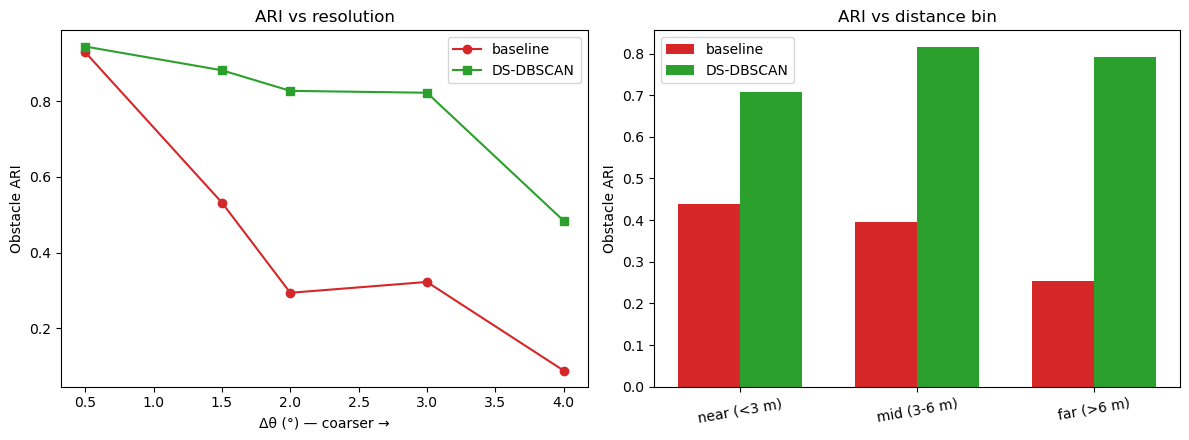

Saved: exp6_distance_results.csv, exp6_sobj_sensitivity.csv, fig_exp6_distance.png


In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for col, lab, c in [("resolution", None, None)]:
    pass
g = res.groupby("resolution", observed=True)
ax[0].plot(g["ari_b_obs"].mean().index, g["ari_b_obs"].mean().values, "o-", label="baseline", color="#d62728")
ax[0].plot(g["ari_k_obs"].mean().index, g["ari_k_obs"].mean().values, "s-", label="DS-DBSCAN", color="#2ca02c")
ax[0].set_xlabel("Δθ (°) — coarser →"); ax[0].set_ylabel("Obstacle ARI"); ax[0].set_title("ARI vs resolution"); ax[0].legend()

gd = res.groupby("dist_bin", observed=True)
xb = np.arange(len(gd)); w = 0.35
ax[1].bar(xb-w/2, gd["ari_b_obs"].mean().values, w, label="baseline", color="#d62728")
ax[1].bar(xb+w/2, gd["ari_k_obs"].mean().values, w, label="DS-DBSCAN", color="#2ca02c")
ax[1].set_xticks(xb); ax[1].set_xticklabels(gd["ari_b_obs"].mean().index, rotation=10)
ax[1].set_ylabel("Obstacle ARI"); ax[1].set_title("ARI vs distance bin"); ax[1].legend()
plt.tight_layout(); plt.savefig("fig_exp6_distance.png", dpi=150); plt.show()

res.to_csv("exp6_distance_results.csv", index=False)
sens_df.to_csv("exp6_sobj_sensitivity.csv", index=False)
print("Saved: exp6_distance_results.csv, exp6_sobj_sensitivity.csv, fig_exp6_distance.png")

#PLOT DS DBSCAN VS BASELINE


Total unique environments: 100

Available environments:
  [ 0] env_000_res2.0deg_180samp_o12_r9.0x4.5
  [ 1] env_001_res2.0deg_180samp_o15_r8.2x6.4
  [ 2] env_002_res1.5deg_240samp_o14_r6.6x8.9
  [ 3] env_003_res1.5deg_240samp_o8_r9.7x6.8
  [ 4] env_004_res4.0deg_90samp_o6_r6.4x5.4
  [ 5] env_005_res2.0deg_180samp_o5_r7.6x9.6
  [ 6] env_006_res1.5deg_240samp_o10_r6.8x4.5
  [ 7] env_007_res2.0deg_180samp_o7_r8.9x4.1
  [ 8] env_008_res0.5deg_720samp_o11_r7.6x7.8
  [ 9] env_009_res3.0deg_120samp_o8_r4.1x6.9
  [10] env_010_res3.0deg_120samp_o12_r5.3x5.5
  [11] env_011_res3.0deg_120samp_o14_r6.0x5.0
  [12] env_012_res4.0deg_90samp_o10_r7.5x6.0
  [13] env_013_res0.5deg_720samp_o15_r4.5x5.3
  [14] env_014_res1.5deg_240samp_o5_r6.1x7.6
  [15] env_015_res4.0deg_90samp_o10_r4.8x7.9
  [16] env_016_res1.5deg_240samp_o10_r4.3x4.7
  [17] env_017_res3.0deg_120samp_o4_r7.4x4.9
  [18] env_018_res0.5deg_720samp_o4_r4.7x8.7
  [19] env_019_res1.5deg_240samp_o12_r5.7x6.5
  [20] env_020_res0.5deg_720samp_o

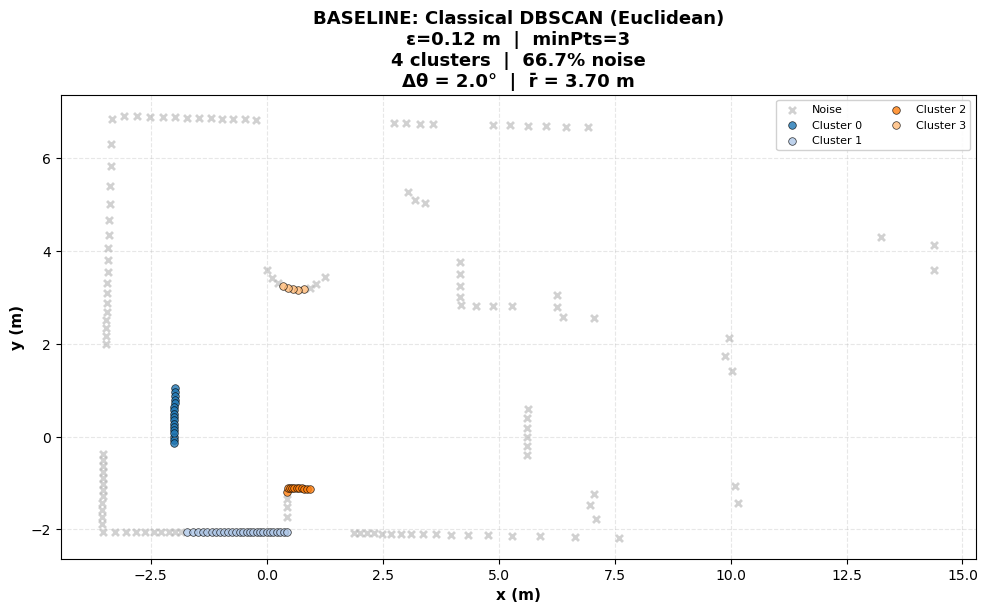

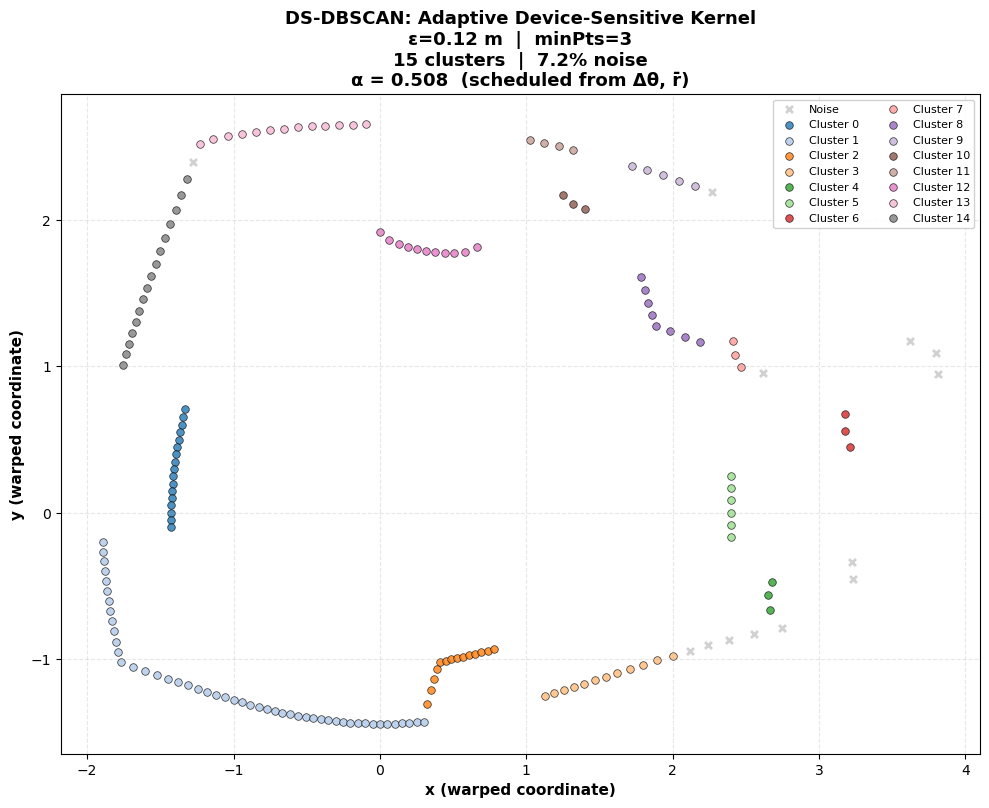

Environment: env_000_res2.0deg_180samp_o12_r9.0x4.5

BASELINE (Classical DBSCAN):
  • Clusters: 4
  • Noise: 66.7%

DS-DBSCAN (Adaptive Kernel):
  • Clusters: 15
  • Noise: 7.2%
  • Kernel exponent α: 0.5077

Improvement:
  • Noise reduction: 59.4 percentage points
  • Cluster count difference: 11

Saved:
  ✓ exp6_baseline_separate.png
  ✓ exp6_kernel_separate.png


In [22]:
# ============================================================================
# Kernel and helper functions
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

from ds_dbscan.kernel import schedule_alpha, transition_range, warp_polar

def sigmoid(z): 
    return 1.0 / (1.0 + np.exp(-z))

def r0_from_device(s_obj_m, dtheta_deg, min_pts=MIN_PTS):
    """Transition range: comes only from the sensor step and object size."""
    return transition_range(s_obj_m, min_pts, np.deg2rad(dtheta_deg))

def alpha_schedule(r_bar_m, r0_m):
    return schedule_alpha(r_bar_m, r0_m, ALPHA_MIN, ALPHA_MAX, TAU)

def points_euclidean(df):
    """Baseline: raw Cartesian (no warp)"""
    r  = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    return np.column_stack([r*np.cos(th), r*np.sin(th)])

def points_kernel(df, s_obj_m):
    """Device-sensitive warp: r' = r^alpha"""
    r  = df["distance_mm"].values / 1000.0
    th = np.deg2rad(df["angle_deg"].values)
    r_bar = np.median(r)
    r0    = r0_from_device(s_obj_m, float(df["resolution"].iloc[0]))
    alpha = alpha_schedule(r_bar, r0)
    return warp_polar(r, th, alpha), alpha

def run_dbscan(pts):
    return DBSCAN(eps=FIXED_EPS, min_samples=MIN_PTS).fit_predict(pts)

def n_clusters(lab):  
    return len(set(lab)) - (1 if -1 in lab else 0)

def noise_pct(lab):   
    return 100.0 * np.sum(lab == -1) / len(lab)

# ============================================================================
# Create enhanced colormap with more distinct colors
# ============================================================================

def create_enhanced_colormap(n_colors=25):
    """Create colormap with many distinct colors + gray for noise (-1)"""
    # Start with tab20 and extend it
    base_colors = plt.cm.tab20(np.linspace(0, 1, 20))
    extended = list(base_colors)
    
    # Add more colors from other colormaps
    if n_colors > 20:
        extra = plt.cm.hsv(np.linspace(0, 0.9, n_colors - 20))
        extended.extend(extra)
    
    # Gray for noise points (label -1)
    noise_color = np.array([0.7, 0.7, 0.7, 1.0])
    
    return extended, noise_color

# ============================================================================
# List ALL unique environments and pick one
# ============================================================================

unique_envs = sorted(master_df["environment_id"].unique())
print(f"\nTotal unique environments: {len(unique_envs)}\n")
print("Available environments:")
for i, env in enumerate(unique_envs):
    print(f"  [{i:2d}] {env}")

# ===== CHANGE THIS NUMBER TO PICK A DIFFERENT ENVIRONMENT =====
env_index = 0  # Pick environment by index (0 to {len(unique_envs)-1})
# ================================================================

env_id = unique_envs[env_index]
df = master_df[master_df["environment_id"] == env_id]

print(f"\n{'='*70}")
print(f"Selected: [{env_index}] {env_id}")
print(f"Rows in this environment: {len(df)}")
print(f"{'='*70}\n")

if len(df) >= MIN_PTS:
    
    # Prepare baseline
    pts_baseline = points_euclidean(df)
    labels_baseline = run_dbscan(pts_baseline)
    
    # Prepare kernel
    pts_kernel, alpha_used = points_kernel(df, S_OBJ_M)
    labels_kernel = run_dbscan(pts_kernel)
    
    # Metrics
    n_clust_b = n_clusters(labels_baseline)
    n_clust_k = n_clusters(labels_kernel)
    noise_b   = noise_pct(labels_baseline)
    noise_k   = noise_pct(labels_kernel)
    resolution_deg = df["resolution"].iloc[0]
    distance_m = df["distance_mm"].median() / 1000.0
    
    # Create enhanced colormap
    colors, noise_color = create_enhanced_colormap(max(n_clust_b, n_clust_k) + 5)
    
    # ========================================================================
    # FIGURE 1: BASELINE
    # ========================================================================
    fig1, ax1 = plt.subplots(figsize=(10, 9))
    
    # Plot noise points (label == -1) in gray first
    noise_mask = labels_baseline == -1
    if noise_mask.sum() > 0:
        ax1.scatter(
            pts_baseline[noise_mask, 0], pts_baseline[noise_mask, 1],
            c=[noise_color], s=25, marker='x', linewidths=2, 
            label='Noise', alpha=0.6
        )
    
    # Plot clusters with distinct colors
    for cluster_id in sorted(set(labels_baseline)):
        if cluster_id == -1:
            continue
        mask = labels_baseline == cluster_id
        color = colors[cluster_id % len(colors)]
        ax1.scatter(
            pts_baseline[mask, 0], pts_baseline[mask, 1],
            c=[color], s=30, label=f'Cluster {cluster_id}', 
            alpha=0.8, edgecolors='black', linewidth=0.5
        )
    
    ax1.set_title(
        f'BASELINE: Classical DBSCAN (Euclidean)\n'
        f'ε={FIXED_EPS} m  |  minPts={MIN_PTS}\n'
        f'{n_clust_b} clusters  |  {noise_b:.1f}% noise\n'
        f'Δθ = {resolution_deg}°  |  r̄ = {distance_m:.2f} m',
        fontweight='bold', fontsize=13
    )
    ax1.set_xlabel('x (m)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('y (m)', fontsize=11, fontweight='bold')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig('exp6_baseline_separate.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ========================================================================
    # FIGURE 2: ADAPTIVE KERNEL
    # ========================================================================
    fig2, ax2 = plt.subplots(figsize=(10, 9))
    
    # Plot noise points (label == -1) in gray first
    noise_mask = labels_kernel == -1
    if noise_mask.sum() > 0:
        ax2.scatter(
            pts_kernel[noise_mask, 0], pts_kernel[noise_mask, 1],
            c=[noise_color], s=25, marker='x', linewidths=2, 
            label='Noise', alpha=0.6
        )
    
    # Plot clusters with distinct colors
    for cluster_id in sorted(set(labels_kernel)):
        if cluster_id == -1:
            continue
        mask = labels_kernel == cluster_id
        color = colors[cluster_id % len(colors)]
        ax2.scatter(
            pts_kernel[mask, 0], pts_kernel[mask, 1],
            c=[color], s=30, label=f'Cluster {cluster_id}', 
            alpha=0.8, edgecolors='black', linewidth=0.5
        )
    
    ax2.set_title(
        f'DS-DBSCAN: Adaptive Device-Sensitive Kernel\n'
        f'ε={FIXED_EPS} m  |  minPts={MIN_PTS}\n'
        f'{n_clust_k} clusters  |  {noise_k:.1f}% noise\n'
        f'α = {alpha_used:.3f}  (scheduled from Δθ, r̄)',
        fontweight='bold', fontsize=13
    )
    ax2.set_xlabel('x (warped coordinate)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('y (warped coordinate)', fontsize=11, fontweight='bold')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig('exp6_kernel_separate.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("=" * 70)
    print(f"Environment: {env_id}")
    print("=" * 70)
    print(f"\nBASELINE (Classical DBSCAN):")
    print(f"  • Clusters: {n_clust_b}")
    print(f"  • Noise: {noise_b:.1f}%")
    print(f"\nDS-DBSCAN (Adaptive Kernel):")
    print(f"  • Clusters: {n_clust_k}")
    print(f"  • Noise: {noise_k:.1f}%")
    print(f"  • Kernel exponent α: {alpha_used:.4f}")
    print(f"\nImprovement:")
    print(f"  • Noise reduction: {noise_b - noise_k:.1f} percentage points")
    print(f"  • Cluster count difference: {abs(n_clust_k - n_clust_b)}")
    print("=" * 70)
    print("\nSaved:")
    print("  ✓ exp6_baseline_separate.png")
    print("  ✓ exp6_kernel_separate.png")

else:
    print(f"⚠ Not enough points in environment (need {MIN_PTS}, got {len(df)})")